# **🎬 Netflix Movies & TV Shows**

---


## Advanced Exploratory Data Analysis (EDA)


## **1. Project Overview**

---



This project performs an in-depth exploratory data analysis of the
Netflix Movies and TV Shows dataset using Python.

The analysis focuses on data quality, content distribution, temporal
trends, ratings, genres, countries, duration patterns, and relationships
between different variables using statistical analysis and advanced
visualizations.

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [182]:
# Load the Netflix dataset

df = pd.read_csv('/content/netflix_titles.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [183]:
# Display the first 5 rows

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [184]:
# Check dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


## **2. Dataset Overview**

---



Before performing analysis, we examine the structure, dimensions,
data types, and statistical characteristics of the dataset.

In [185]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [186]:
# Statistical summary of numerical variables

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [187]:
# Check data types of all columns

df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [188]:
# Identify numerical and categorical columns

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['release_year']

Categorical Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [189]:
# Number of unique values in each column

df.nunique().sort_values(ascending=False)

,0
show_id,8807
title,8804
description,8775
cast,7692
director,4528
date_added,1767
country,748
listed_in,514
duration,220
release_year,74


## **3. Data Quality Assessment**

---



We assess missing values and duplicate records to understand the
quality and completeness of the dataset before analysis.

In [190]:
# Check missing values

missing_count = df.isnull().sum()

missing_count[missing_count > 0]

,0
director,2634
cast,825
country,831
date_added,10
rating,4
duration,3


In [191]:
# Calculate missing-value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values('Missing Percentage', ascending=False)

missing_summary

,Missing Values,Missing Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


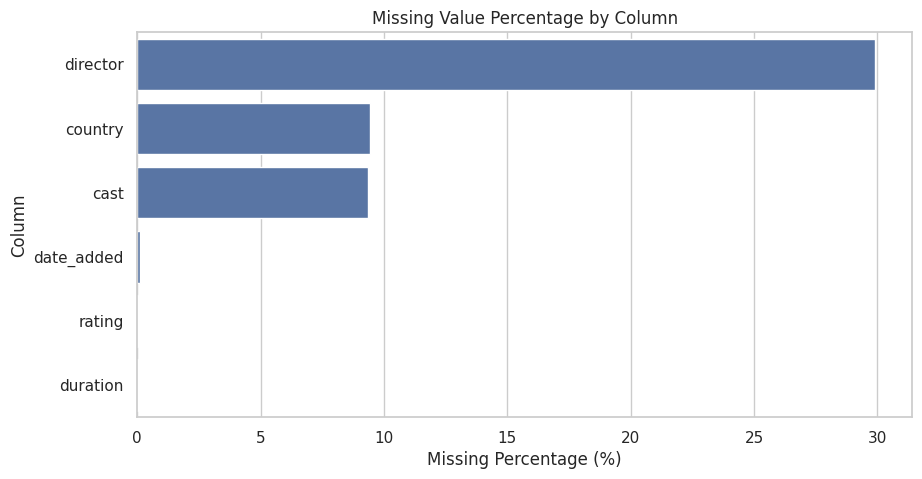

In [192]:
# Visualize missing-value percentages

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_summary['Missing Percentage'],
    y=missing_summary.index
)

plt.title('Missing Value Percentage by Column')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Column')

plt.show()

In [193]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [194]:
# Handle missing values in selected categorical columns

for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('Unknown')

print("Missing values in director, cast, and country handled successfully.")

Missing values in director, cast, and country handled successfully.


In [195]:
# Verify missing values after treatment

df[['director', 'cast', 'country']].isnull().sum()

,0
director,0
cast,0
country,0


In [196]:
# Create a clean copy
df_clean = df.copy()

# Find duration values wrongly present in rating
rating_is_duration = (
    df_clean['rating']
    .astype('string')
    .str.fullmatch(r'\d+\s*min', na=False)
)

# Move duration to duration column only when duration is missing
move_mask = rating_is_duration & df_clean['duration'].isna()

df_clean.loc[move_mask, 'duration'] = df_clean.loc[move_mask, 'rating']
df_clean.loc[move_mask, 'rating'] = pd.NA

# Check corrected rows
print("Corrected rows:", move_mask.sum())

# Rating distribution
rating_type = (
    df_clean[['type', 'rating']]
    .dropna()
    .groupby(['rating', 'type'])
    .size()
    .reset_index(name='count')
)

rating_type

Corrected rows: 3


,rating,type,count
0,G,Movie,41
1,NC-17,Movie,3
2,NR,Movie,75
3,NR,TV Show,5
4,PG,Movie,287
5,PG-13,Movie,490
6,R,Movie,797
7,R,TV Show,2
8,TV-14,Movie,1427
9,TV-14,TV Show,733


In [197]:
# Check duplicate records

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [198]:
# Convert date_added to datetime format

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print("date_added converted to datetime.")

date_added converted to datetime.


In [199]:
# Verify the updated data types

df[['date_added']].dtypes

,0
date_added,datetime64[ns]


## **4. Univariate Analysis**

---



Univariate analysis examines the distribution and characteristics of
individual variables independently.


### 4.1 Content Type Distribution

We begin by examining the distribution of Movies and TV Shows in the
Netflix catalog.

In [200]:
# Count of Movies and TV Shows

content_type_counts = df['type'].value_counts()

print(content_type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


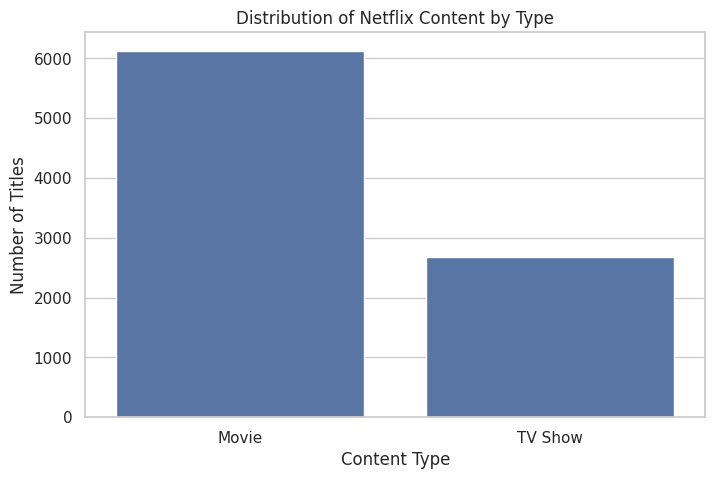

In [201]:
# Visualize content type distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='type'
)

plt.title('Distribution of Netflix Content by Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

### 4.2 Top 10 Countries by Number of Titles

This analysis identifies the countries contributing the highest number
of titles to the Netflix catalog.


In [202]:
# Top 10 countries

top_countries = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

top_countries

,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


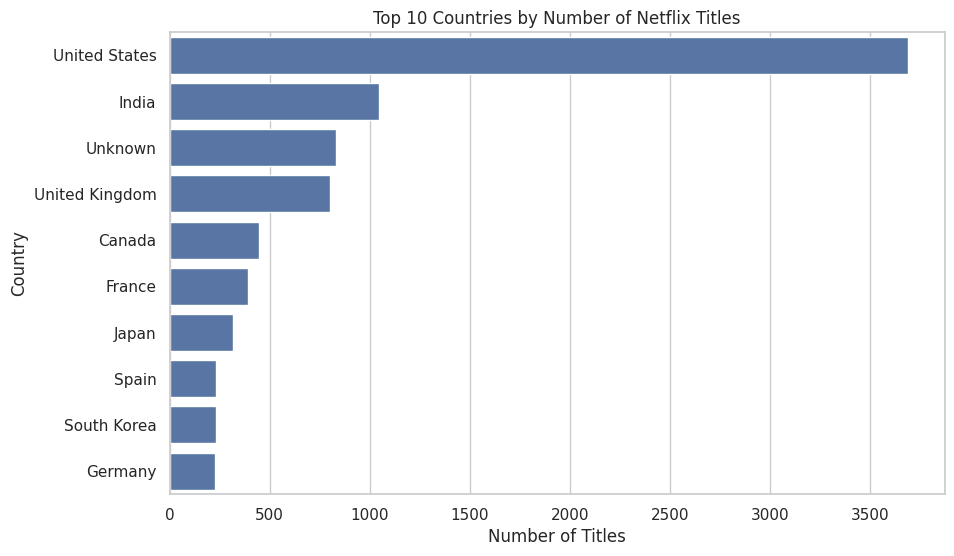

In [203]:
# Visualize top 10 countries

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

### 4.3 Genre Distribution

This analysis examines the most frequently occurring genres in the
Netflix catalog.

In [204]:
# Top 10 genres

top_genres = (
    df['listed_in']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


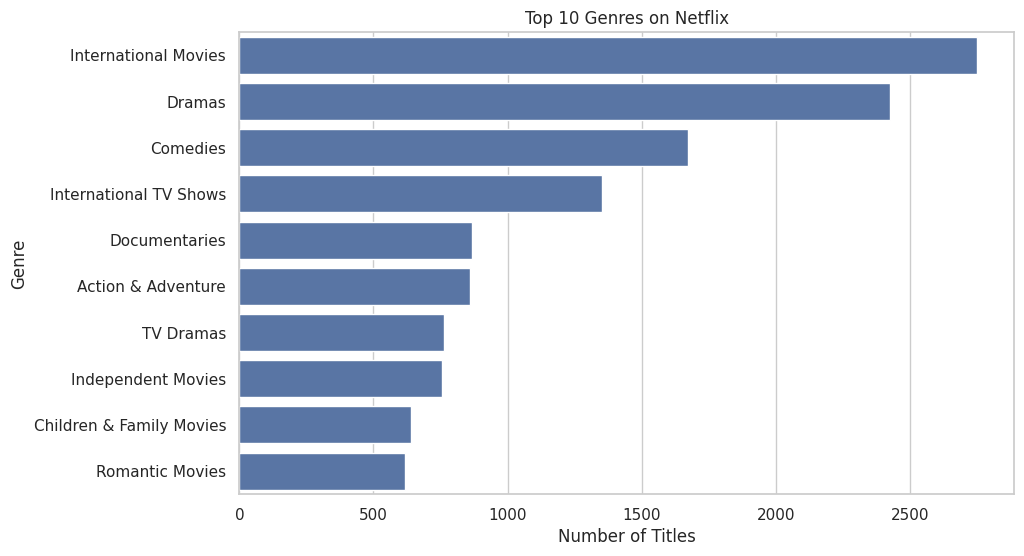

In [205]:
# Visualize top 10 genres

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

### 4.4 Content Rating Distribution

This analysis examines the frequency distribution of content ratings
across the Netflix catalog.

In [206]:
# Top 10 content ratings

top_ratings = (
    df['rating']
    .dropna()
    .value_counts()
    .head(10)
)

top_ratings

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


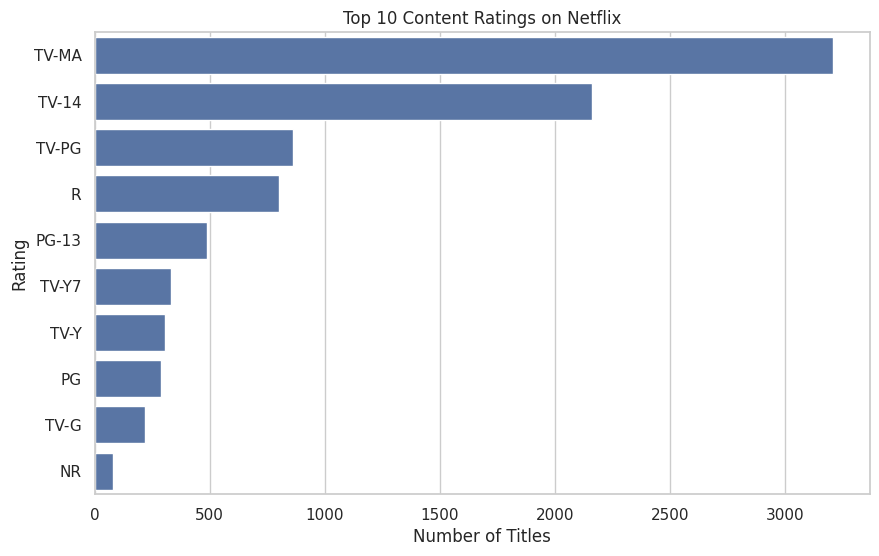

In [207]:
# Visualize top 10 ratings

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.show()

### **Univariate Analysis Summary**

The univariate analysis provides an initial understanding of the
Netflix catalog by examining content type, country, genre, and rating
distributions. These individual-variable patterns provide a foundation
for deeper bivariate and multivariate analysis.

## **5. Bivariate Analysis**

---



Bivariate analysis examines the relationship between two variables
to identify differences, associations, and comparative patterns.

In this section, we compare content type with country and rating,
and examine temporal patterns in Netflix content.

We also use distribution analysis to understand the spread and
potential outliers in numerical variables.

### 5.1 Content Type Distribution Across Top 5 Countries

This analysis compares the number of Movies and TV Shows across the
five countries with the highest number of Netflix titles.

This helps identify differences in content composition across
major content-producing countries.

In [208]:
# Identify the top 5 countries

top_5_countries = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(5)
)

top_5_countries

,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445


In [209]:
# Prepare country and content-type data

country_type = df[['type', 'country']].dropna().copy()

country_type['country'] = country_type['country'].str.split(', ')

country_type = country_type.explode('country')

country_type = country_type[
    country_type['country'].isin(top_5_countries.index)
]

country_type_counts = (
    country_type
    .groupby(['country', 'type'])
    .size()
    .reset_index(name='count')
)

country_type_counts

,country,type,count
0,Canada,Movie,319
1,Canada,TV Show,126
2,India,Movie,962
3,India,TV Show,84
4,United Kingdom,Movie,532
5,United Kingdom,TV Show,272
6,United States,Movie,2751
7,United States,TV Show,938
8,Unknown,Movie,440
9,Unknown,TV Show,391


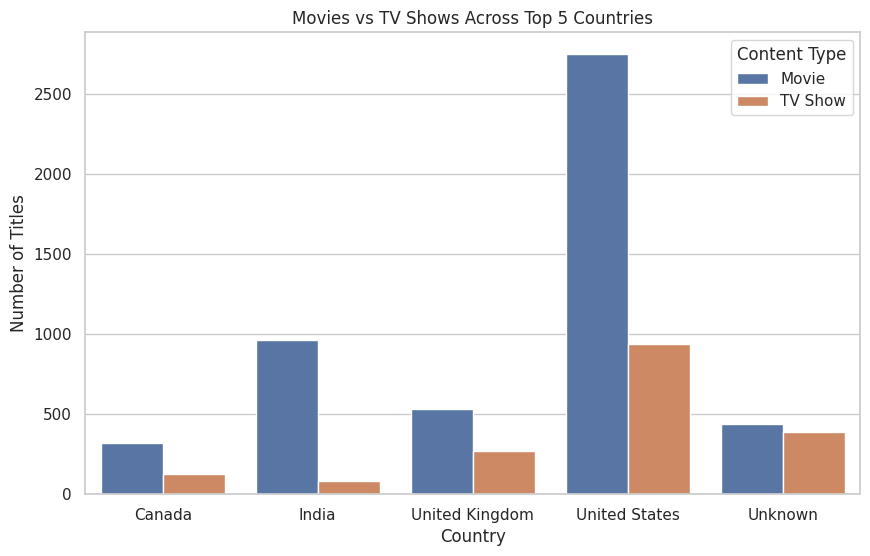

In [210]:
# Compare Movies and TV Shows across the top 5 countries

plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_type_counts,
    x='country',
    y='count',
    hue='type'
)

plt.title('Movies vs TV Shows Across Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')

plt.show()

### 5.2 Content Rating Distribution by Content Type

This analysis compares content ratings between Movies and TV Shows
to identify differences in rating composition across content types.

In [211]:
# Calculate rating distribution by content type

rating_type = (
    df_clean[['type', 'rating']]
    .dropna()
    .groupby(['rating', 'type'])
    .size()
    .reset_index(name='count')
)

rating_type

,rating,type,count
0,G,Movie,41
1,NC-17,Movie,3
2,NR,Movie,75
3,NR,TV Show,5
4,PG,Movie,287
5,PG-13,Movie,490
6,R,Movie,797
7,R,TV Show,2
8,TV-14,Movie,1427
9,TV-14,TV Show,733


In [212]:
# Create a pivot table for the heatmap

rating_heatmap = rating_type.pivot(
    index='rating',
    columns='type',
    values='count'
).fillna(0)

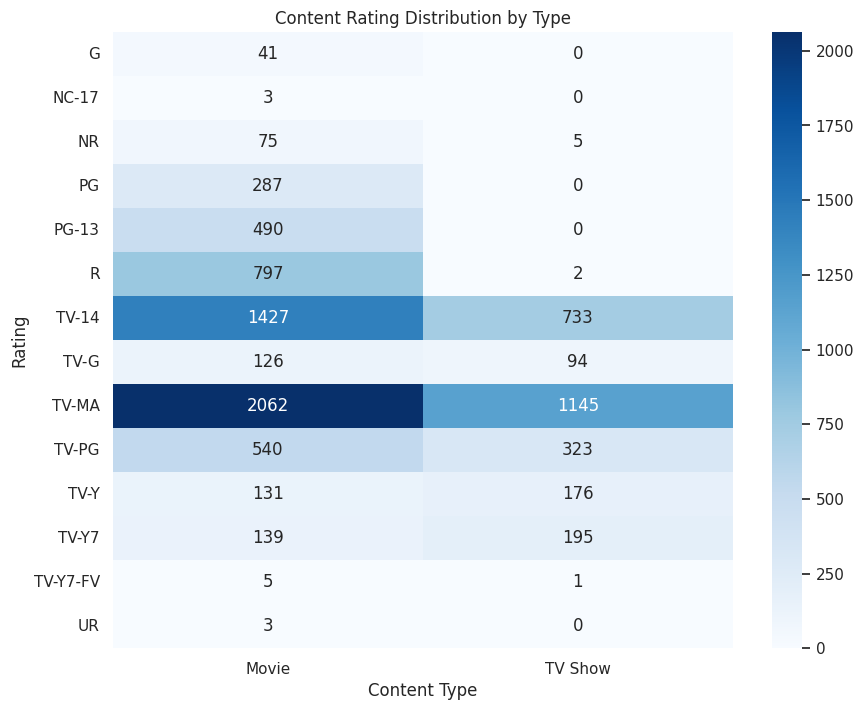

In [213]:
# Visualize rating distribution using a heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Content Rating Distribution by Type')
plt.xlabel('Content Type')
plt.ylabel('Rating')

plt.show()

### 5.3 Temporal Trend Analysis

This analysis examines the distribution of Netflix titles across
release years to identify long-term temporal patterns.

In [214]:
# Count titles by release year

yearly_content = (
    df['release_year']
    .value_counts()
    .sort_index()
)

yearly_content.head()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4


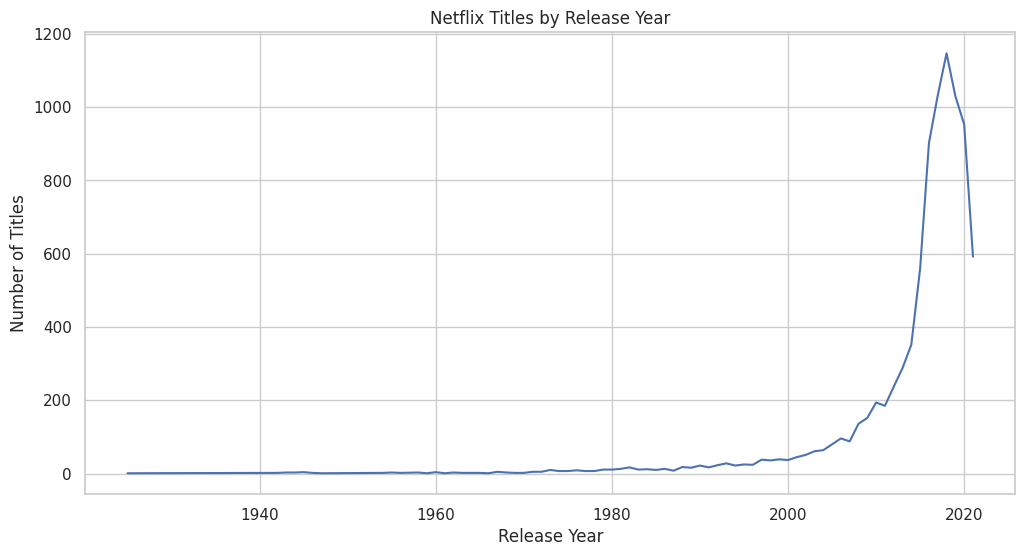

In [215]:
# Visualize the release-year trend

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_content.index,
    y=yearly_content.values
)

plt.title('Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

### 5.4 Release Year Distribution

A histogram is used to examine the frequency distribution of
Netflix titles across release years and identify periods where
content is more concentrated.

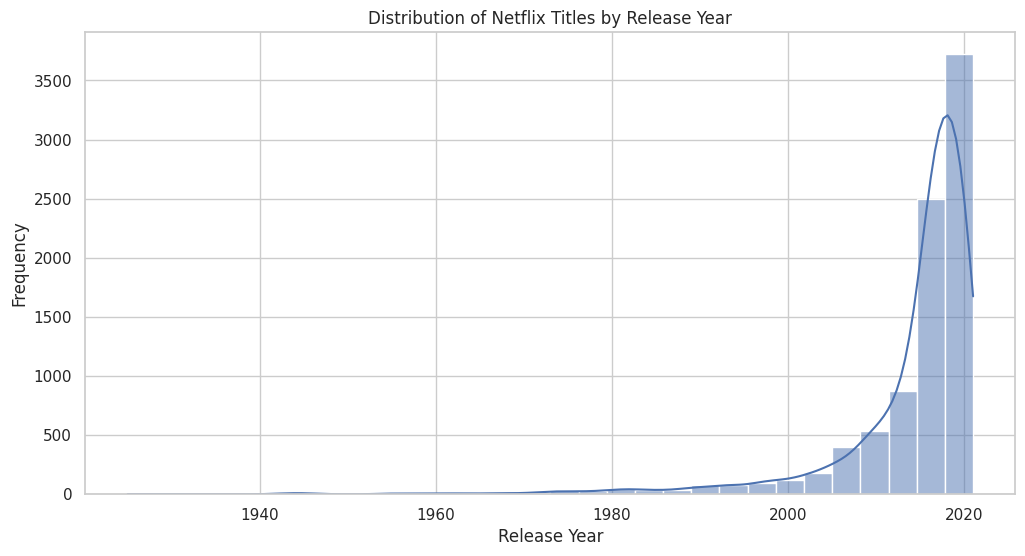

In [216]:
# Distribution of release years

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='release_year',
    bins=30,
    kde=True
)

plt.title('Distribution of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

### 5.5 Movie Duration Distribution

This analysis examines the distribution of movie durations and
identifies the central tendency, spread, and potential outliers.

In [217]:
# Extract numeric duration for Movies

movie_duration = df[df['type'] == 'Movie'].copy()

movie_duration['duration_minutes'] = (
    movie_duration['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

movie_duration[['duration', 'duration_minutes']].head()

,duration,duration_minutes
0,90 min,90.0
6,91 min,91.0
7,125 min,125.0
9,104 min,104.0
12,127 min,127.0


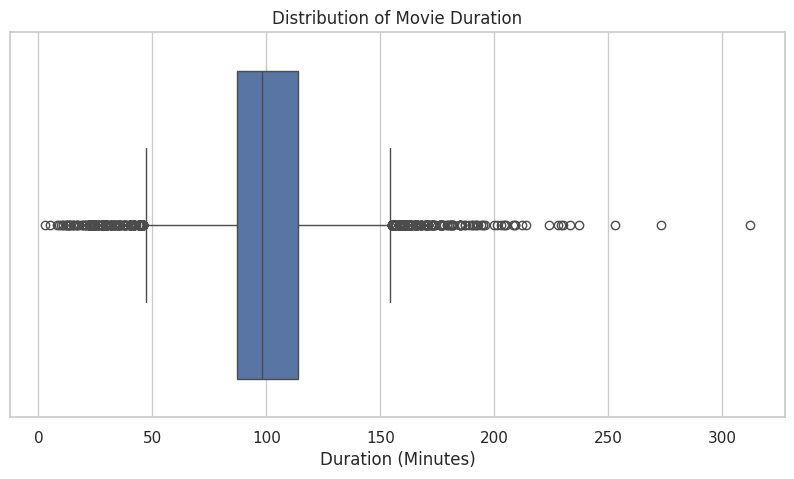

In [218]:
# Box plot for movie duration

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=movie_duration['duration_minutes']
)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')

plt.show()

### 5.6 Movie Duration Frequency Distribution

A histogram is used to understand the frequency distribution of
movie durations and identify the range in which most movies are
concentrated.

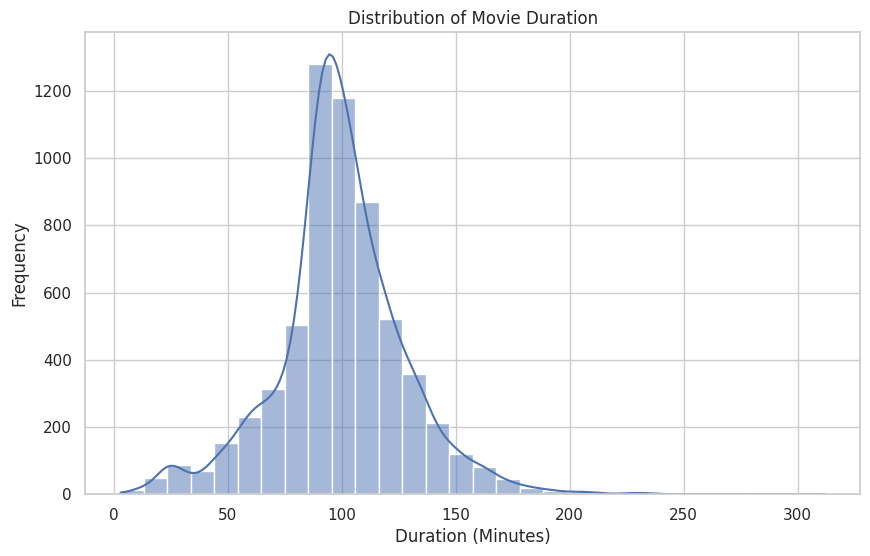

In [219]:
# Histogram of movie duration

plt.figure(figsize=(10, 6))

sns.histplot(
    data=movie_duration,
    x='duration_minutes',
    bins=30,
    kde=True
)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')

plt.show()

### **Bivariate and Distribution Analysis Summary**

The analysis compared Netflix content across countries, content types,
and ratings to identify categorical relationships and differences.

Temporal analysis was used to examine content patterns across release
years, while histogram and box plot visualizations were used to study
the distribution and variability of numerical variables such as movie
duration.

These analyses provide a deeper understanding of the Netflix catalog
and establish a foundation for further multivariate analysis.

## **6. Multivariate Analysis**

---



Multivariate analysis examines multiple variables simultaneously to
identify deeper patterns and relationships within the Netflix catalog.

In this section, content type, rating, and country are analysed together.

### 6.1 Content Type Distribution Across Top Countries

This analysis examines how the distribution of Movies and TV Shows
varies across the top five countries in the Netflix catalog.

In [220]:
# Prepare data for multivariate analysis

multi_data = df[['country', 'type', 'rating']].dropna().copy()

multi_data['country'] = multi_data['country'].str.split(', ')

multi_data = multi_data.explode('country')

multi_data = multi_data[
    multi_data['country'].isin(top_5_countries.index)
]

multi_data.head()

,country,type,rating
0,United States,Movie,PG-13
2,Unknown,TV Show,TV-MA
3,Unknown,TV Show,TV-MA
4,India,TV Show,TV-MA
5,Unknown,TV Show,TV-MA


In [221]:
# Count ratings across top countries and content types

country_rating_type = (
    multi_data
    .groupby(['country', 'type', 'rating'])
    .size()
    .reset_index(name='count')
)

country_rating_type.head(10)

,country,type,rating,count
0,Canada,Movie,G,2
1,Canada,Movie,NC-17,1
2,Canada,Movie,NR,5
3,Canada,Movie,PG,33
4,Canada,Movie,PG-13,32
5,Canada,Movie,R,79
6,Canada,Movie,TV-14,29
7,Canada,Movie,TV-G,8
8,Canada,Movie,TV-MA,72
9,Canada,Movie,TV-PG,25


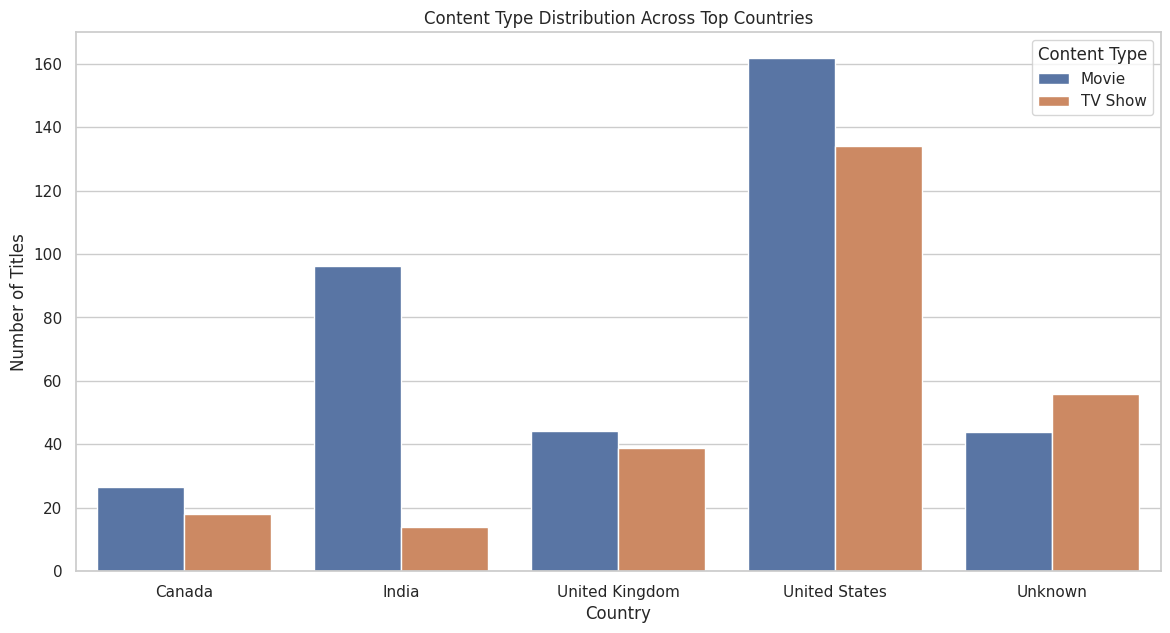

In [222]:
# Multivariate comparison of ratings across countries and content types

plt.figure(figsize=(14, 7))

sns.barplot(
    data=country_rating_type,
    x='country',
    y='count',
    hue='type',
    errorbar=None
)

plt.title('Content Type Distribution Across Top Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')

plt.show()

### 6.2 Genre Distribution by Content Type

This analysis examines how genre composition differs between Movies
and TV Shows.

In [223]:
# Prepare genre and content type data

genre_type = df[['listed_in', 'type']].dropna().copy()

genre_type['listed_in'] = genre_type['listed_in'].str.split(', ')

genre_type = genre_type.explode('listed_in')

genre_type_counts = (
    genre_type
    .groupby(['listed_in', 'type'])
    .size()
    .reset_index(name='count')
)

# Select top 10 genres overall

top_10_genres = (
    genre_type['listed_in']
    .value_counts()
    .head(10)
    .index
)

genre_type_top10 = genre_type_counts[
    genre_type_counts['listed_in'].isin(top_10_genres)
]

genre_type_top10

,listed_in,type,count
0,Action & Adventure,Movie,859
4,Children & Family Movies,Movie,641
7,Comedies,Movie,1674
10,Documentaries,Movie,869
12,Dramas,Movie,2427
15,Independent Movies,Movie,756
16,International Movies,Movie,2752
17,International TV Shows,TV Show,1351
24,Romantic Movies,Movie,616
34,TV Dramas,TV Show,763


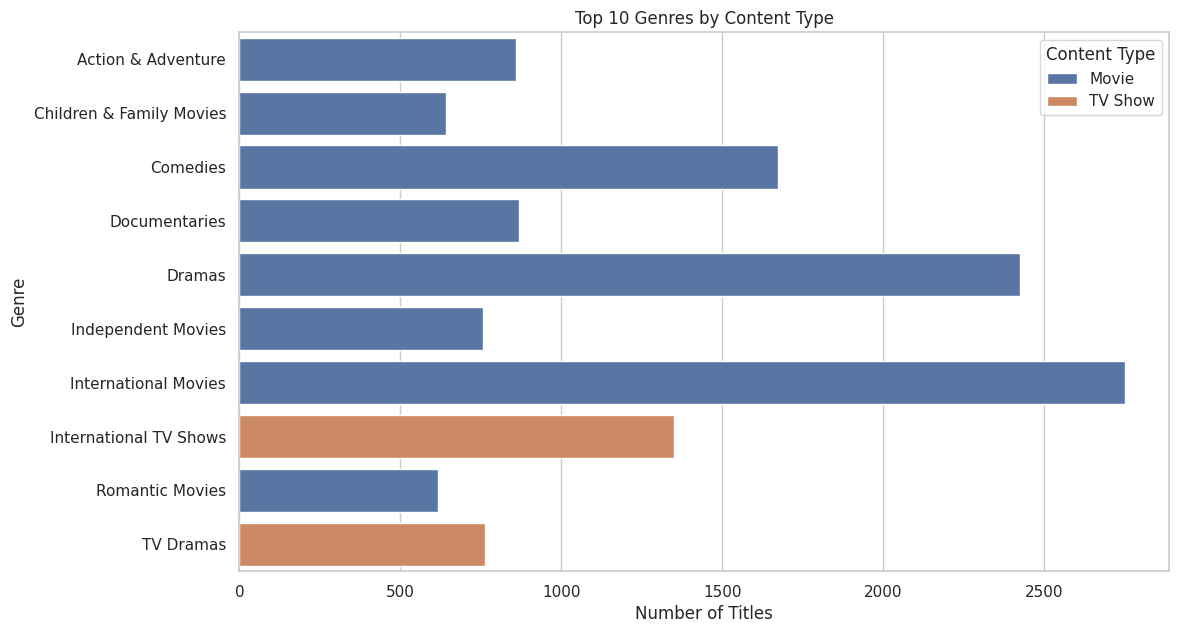

In [224]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_type_top10,
    x='count',
    y='listed_in',
    hue='type',
    errorbar=None
)

plt.title('Top 10 Genres by Content Type')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.legend(title='Content Type')

plt.show()

In [225]:
# Filter only Movies
movies_df = df[df['type'] == 'Movie'].copy()

# Convert movie duration into numeric minutes
movies_df['duration_minutes'] = (
    movies_df['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Select numerical variables
numeric_data = movies_df[['release_year', 'duration_minutes']]

numeric_data.head()

,release_year,duration_minutes
0,2020,90.0
6,2021,91.0
7,1993,125.0
9,2021,104.0
12,2021,127.0


In [226]:
# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

correlation_matrix

,release_year,duration_minutes
release_year,1.000000,-0.206285
duration_minutes,-0.206285,1.000000


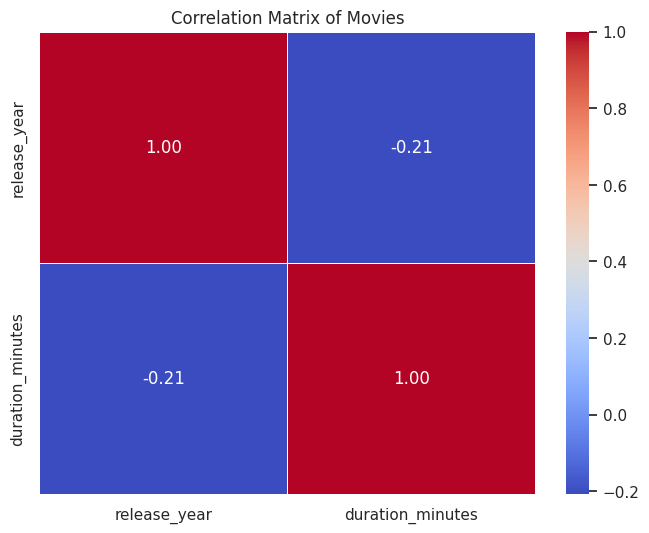

In [227]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Movies')
plt.show()

### Multivariate Analysis Summary

Multivariate analysis provides a deeper view of the Netflix catalog by
examining multiple dimensions simultaneously. The analysis highlights
differences in genre composition across content types and explores
relationships among numerical variables through correlation analysis.

## **7. Advanced Content Analysis**

---



This section provides deeper comparative analysis of Netflix content
using proportions, distributions, and category-level patterns.

In [228]:
# Calculate percentage distribution of content types

content_percentage = (
    df['type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

content_percentage

,proportion
type,
Movie,69.62
TV Show,30.38


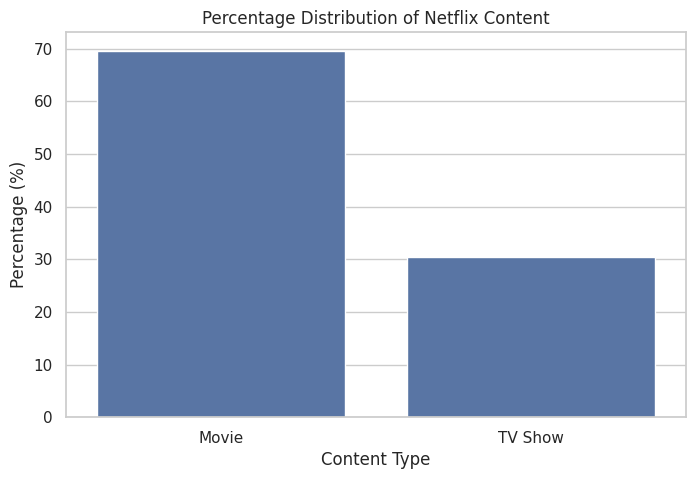

In [229]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=content_percentage.index,
    y=content_percentage.values
)

plt.title('Percentage Distribution of Netflix Content')
plt.xlabel('Content Type')
plt.ylabel('Percentage (%)')

plt.show()

In [230]:
# Descriptive statistics for movie duration

movie_duration['duration_minutes'].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


In [231]:
# Calculate IQR for movie duration

Q1 = movie_duration['duration_minutes'].quantile(0.25)
Q3 = movie_duration['duration_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 87.0
Q3: 114.0
IQR: 27.0
Lower Bound: 46.5
Upper Bound: 154.5


In [232]:
# Identify potential outliers

outliers = movie_duration[
    (movie_duration['duration_minutes'] < lower_bound) |
    (movie_duration['duration_minutes'] > upper_bound)
]

print("Potential outliers:", len(outliers))

Potential outliers: 450


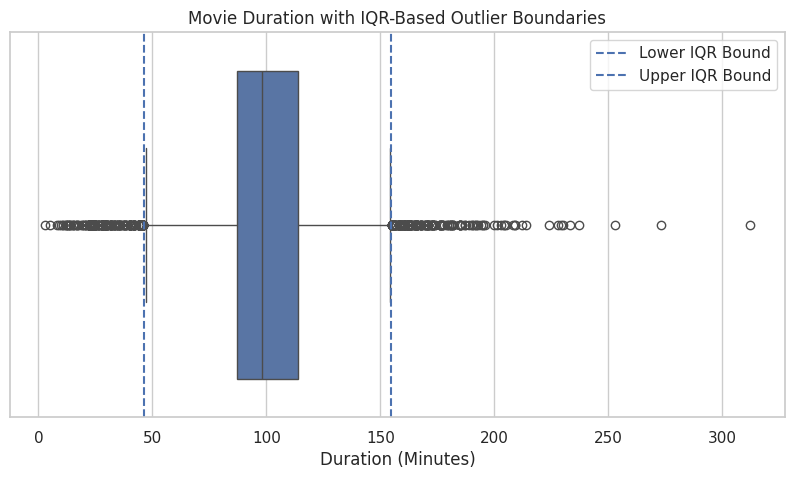

In [233]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=movie_duration['duration_minutes']
)

plt.axvline(
    lower_bound,
    linestyle='--',
    label='Lower IQR Bound'
)

plt.axvline(
    upper_bound,
    linestyle='--',
    label='Upper IQR Bound'
)

plt.title('Movie Duration with IQR-Based Outlier Boundaries')
plt.xlabel('Duration (Minutes)')
plt.legend()

plt.show()

In [234]:
# Calculate percentage contribution of top genres

genre_percentage = (
    top_genres
    .div(top_genres.sum())
    .mul(100)
    .round(2)
)

genre_percentage

,count
listed_in,
International Movies,21.66
Dramas,19.10
Comedies,13.17
International TV Shows,10.63
Documentaries,6.84
Action & Adventure,6.76
TV Dramas,6.00
Independent Movies,5.95
Children & Family Movies,5.04


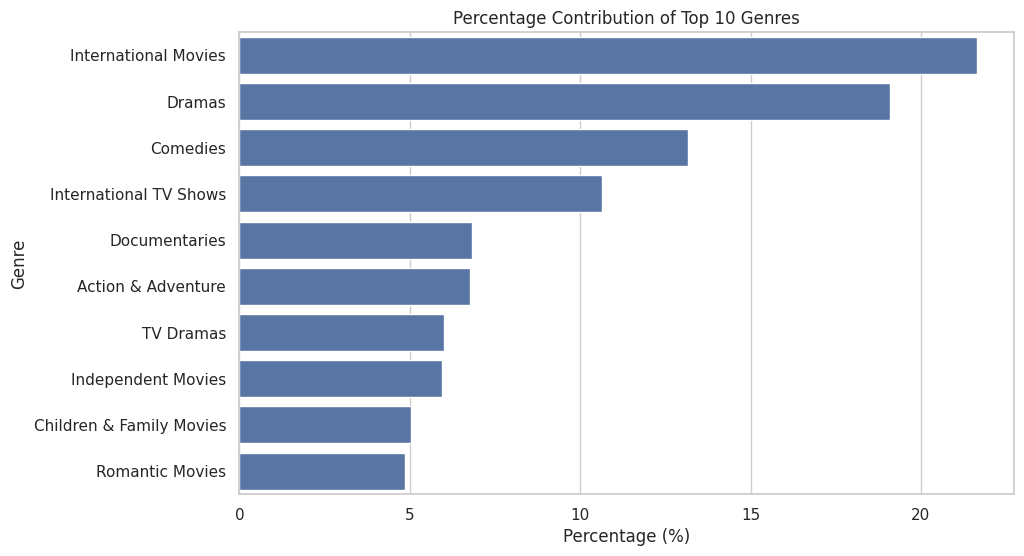

In [235]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_percentage.values,
    y=genre_percentage.index
)

plt.title('Percentage Contribution of Top 10 Genres')
plt.xlabel('Percentage (%)')
plt.ylabel('Genre')

plt.show()

### Advanced Analysis Summary

The advanced analysis examines proportional content distribution,
descriptive statistics, variability, and potential outliers in movie
duration. Relative frequency analysis is also used to understand the
contribution of major genres to the overall catalog.

These analyses provide deeper statistical context beyond simple
frequency counts.

## **8. Key Findings and Insights**

---



The following insights summarize the major patterns, distributions,
comparisons, and statistical observations identified during the
exploratory data analysis.


- The Netflix catalog shows a clear difference in the distribution of Movies and TV Shows.
- Content is geographically concentrated among a limited number of countries.
- The genre distribution indicates that certain content categories dominate the Netflix catalog.
- Content ratings show distinct frequency patterns across the catalog.
- Release-year analysis reveals a changing distribution of Netflix content over time.
- Movie durations show variation in central tendency and dispersion, with potential outliers identified using the IQR method.
- The distribution of ratings differs between Movies and TV Shows, indicating differences in their content composition.
- Multivariate analysis reveals differences in genre and content-type patterns across major countries.

In [236]:
# Key numerical summaries

print("Total Titles:", len(df))
print("\nContent Type Distribution:")
print(df['type'].value_counts())

print("\nTop 5 Countries:")
print(top_5_countries)

print("\nTop 5 Genres:")
print(top_genres.head())

print("\nTop Ratings:")
print(top_ratings.head())

Total Titles: 8807

Content Type Distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top 5 Countries:
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64

Top 5 Genres:
listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

Top Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


In [237]:
# Movie duration statistics

movie_duration['duration_minutes'].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


In [238]:
# Most frequent release years

df['release_year'].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


In [239]:
# Missing-value summary after cleaning

df.isnull().sum().sort_values(ascending=False).head(10)

,0
date_added,98
rating,4
duration,3
show_id,0
director,0
title,0
type,0
cast,0
release_year,0
country,0


## **9. Conclusion**

---



- This project provided an in-depth exploratory analysis of the Netflix
Movies and TV Shows dataset using Python.

- The analysis covered data quality assessment, data cleaning, univariate,
bivariate, and multivariate analysis, temporal trends, content ratings,
genre distribution, country-level patterns, and movie duration.

- Pandas was used for data manipulation and preprocessing, NumPy for
numerical operations, while Matplotlib and Seaborn were used to create
meaningful visualizations.

- Statistical techniques such as descriptive statistics and the IQR
method were also applied to understand data distribution and identify
potential outliers.

- Overall, the project demonstrates how exploratory data analysis can be
used to transform raw data into meaningful patterns, comparisons, and
data-driven insights.

## **10. Project Summary**

---



### **Dataset**

- Netflix Movies & TV Shows Dataset

### **Programming Language**
- Python

### **Libraries Used**
- Pandas
- NumPy
- Matplotlib
- Seaborn

### **Key Analytical Techniques**
- Data Cleaning
- Missing Value Analysis
- Duplicate Analysis
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Temporal Trend Analysis
- Distribution Analysis
- Descriptive Statistics
- IQR-Based Outlier Detection
- Categorical Frequency Analysis
- Comparative Analysis

### **Visualization Techniques**
- Count Plot
- Bar Plot
- Grouped Bar Plot
- Line Plot
- Histogram
- KDE Plot
- Box Plot
- Heatmap